In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import datetime
from scipy.constants import mu_0

In [2]:
cop24 = np.load('cop24.npz')

ex_raw = cop24['ex_raw']
ey_raw = cop24['ey_raw']
hx_raw = cop24['hx_raw']
hy_raw = cop24['hy_raw']

cop24_start = datetime.datetime.fromisoformat("2018-09-13T15:14:30+00:00")
cop24_end = datetime.datetime.fromisoformat("2018-10-01T06:27:33+00:00")

cop24_az = {
    'ex': 334.3 * np.pi/180, #degrees
    'ey': 64.3 * np.pi/180,
    'hx': 8.3 * np.pi/180,
    'hy' : 98.3 * np.pi/180,
}

e_hp = np.c_[ex_raw, ey_raw]
h_hp = np.c_[hx_raw, hy_raw]

th = np.pi/2 - cop24_az['ex']
u_ex = np.r_[np.cos(th), np.sin(th)]

th = np.pi/2 - cop24_az['ey']
u_ey = np.r_[np.cos(th), np.sin(th)]

U_e = np.c_[u_ex, u_ey]

th = np.pi/2 - cop24_az['hx']
u_hx = np.r_[np.cos(th), np.sin(th)]

th = np.pi/2 - cop24_az['hy']
u_hy = np.r_[np.cos(th), np.sin(th)]

U_h = np.c_[u_hx, u_hy]

e_r = np.linalg.solve(U_e, e_hp[..., None])[..., 0]
h_r = np.linalg.solve(U_h, h_hp[..., None])[..., 0]

ex_raw, ey_raw = e_r.T
hx_raw, hy_raw = h_r.T

cop24_raw = {'ex':ex_raw, 'ey':ey_raw, 'hx':hx_raw, 'hy':hy_raw}

In [3]:
coo24 = np.load('coo24.npz')

ex_raw = coo24['ex_raw']
ey_raw = coo24['ey_raw']
hx_raw = coo24['hx_raw']
hy_raw = coo24['hy_raw']

coo24_start = datetime.datetime.fromisoformat("2018-09-12T15:39:54+00:00")
coo24_end = datetime.datetime.fromisoformat("2018-09-25T19:26:45+00:00")

coo24_az = {
    'ex': 337.4 * np.pi/180, #degrees
    'ey': 67.4 * np.pi/180,
    'hx': 8.4 * np.pi/180,
    'hy' : 98.4 * np.pi/180,
}

e_hp = np.c_[ex_raw, ey_raw]
h_hp = np.c_[hx_raw, hy_raw]

th = np.pi/2 - coo24_az['ex']
u_ex = np.r_[np.cos(th), np.sin(th)]

th = np.pi/2 - coo24_az['ey']
u_ey = np.r_[np.cos(th), np.sin(th)]

U_e = np.c_[u_ex, u_ey]

th = np.pi/2 - coo24_az['hx']
u_hx = np.r_[np.cos(th), np.sin(th)]

th = np.pi/2 - coo24_az['hy']
u_hy = np.r_[np.cos(th), np.sin(th)]

U_h = np.c_[u_hx, u_hy]

e_or = np.linalg.solve(U_e, e_hp[..., None])[..., 0]
h_or = np.linalg.solve(U_h, h_hp[..., None])[..., 0]

e_r = np.linalg.solve(U_e, e_hp[..., None])[..., 0]
h_r = np.linalg.solve(U_h, h_hp[..., None])[..., 0]

ex_raw, ey_raw = e_r.T
hx_raw, hy_raw = h_r.T

coo24_raw = {'ex':ex_raw, 'ey':ey_raw, 'hx':hx_raw, 'hy':hy_raw}

In [4]:
# select overlapping times
d_start = cop24_start - coo24_start
d_end = coo24_end - cop24_end

start_time = max(cop24_start, coo24_start)
end_time = min(coo24_end, cop24_end)

cop24_start_ind = int((start_time - cop24_start).total_seconds())
cop24_end_ind = int((end_time - cop24_start).total_seconds())+1

coo24_start_ind = int((start_time - coo24_start).total_seconds())
coo24_end_ind = int((end_time - coo24_start).total_seconds())+1

cop24_overlapped = {
    key:value[cop24_start_ind:cop24_end_ind] for key, value in cop24_raw.items()
}

coo24_overlapped = {
    key:value[coo24_start_ind:coo24_end_ind] for key, value in coo24_raw.items()
}

In [5]:
dipole_length = 100
e_gain = 409600000.0

start = datetime.datetime.fromisoformat("2018-09-13T15:14:30+00:00")
end = datetime.datetime.fromisoformat("2018-10-01T06:27:33+00:00")
sample_rate = 1 #Hz

time_delay = {
    "ex":datetime.timedelta(seconds=-0.285),
    "ey":datetime.timedelta(seconds=-0.285),
    "hx":datetime.timedelta(seconds=-0.192),
    "hy":datetime.timedelta(seconds=-0.201),
    "hz":datetime.timedelta(seconds=-0.21),
}

nims_low_pass_e = {
    'p':[-3.883009+11.951875j,-3.883009-11.951875j,-10.166194 +7.386513j,-10.166194 -7.386513j,-12.566371 +0.j],
    'z': [],
    'k':313383.493219835
}

nims_high_pass_e = {
    'p':[-0.000167, ],
    'z':[0.0],
    'k':1.00000000378188,
}


h_gain = 100
nims_low_pass_h = {
    'p':[-6.283185+10.882477j, -6.283185-10.882477j,-12.566371+0.j],
    'z':[],
    'k':2002.26936395594 * 1E9 * mu_0 # 1E-9 / mu_0 # V/nT -> , # last bit is nT -> A/m
}

In [6]:
n_samples = len(cop24_overlapped['ex'])
n_divisions = 10
print(n_samples)

1051936


In [7]:
n_leftovers = n_samples % n_divisions
cop24_slices = {
    key:value[:-n_leftovers].reshape(n_divisions, -1) for key, value in cop24_overlapped.items()
}
coo24_slices = {
    key:value[:-n_leftovers].reshape(n_divisions, -1) for key, value in coo24_overlapped.items()
}
n_window = cop24_slices['ex'].shape[-1]
n_window

105193

In [8]:
it = np.arange(n_window)
def remove_trend(x, it=it):
    p1, p0 = np.polyfit(it, x.T, 1)
    return x - (p1[:, None]*it + p1[:, None])

In [9]:
cop24_dt = {key:remove_trend(value) for key, value in cop24_slices.items()}
coo24_dt = {key:remove_trend(value) for key, value in coo24_slices.items()}

In [10]:
window = sig.windows.hamming(n_window)

In [11]:
cop24_fft = {key:np.fft.rfft(value * window)[..., 1:] for key, value in cop24_dt.items()}
coo24_fft = {key:np.fft.rfft(value * window)[..., 1:] for key, value in coo24_dt.items()}

In [12]:
coo24_fft['ex'].shape

(10, 52596)

In [13]:
f = np.fft.rfftfreq(n_window, 1)[1:]

In [14]:
omega = 2 * np.pi * f
_, e_lowpass = sig.freqs_zpk(**nims_low_pass_e, worN=omega)
_, e_highpass = sig.freqs_zpk(**nims_high_pass_e, worN=omega)

_, h_lowpass = sig.freqs_zpk(**nims_low_pass_h, worN=omega)

def do_cal(key, value):
    if key in ["ex", "ey"]:
        return value / (e_gain * dipole_length * e_lowpass * e_highpass)
    elif key in ['hx','hy','hz']:
        return value / (h_gain * h_lowpass)

In [15]:
cop24_FC = {key:do_cal(key, value) for key, value in cop24_fft.items()}
coo24_FC = {key:do_cal(key, value) for key, value in coo24_fft.items()}

In [16]:
period_bands = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(24000), 9)[1:]
]
n_bands = len(period_bands) - 1

freq_bands = 1.0/period_bands[::-1]
freq_bands

array([4.16666667e-05, 6.19890761e-05, 9.22234933e-05, 1.37204379e-04,
       2.04124145e-04, 3.03683212e-04, 4.51801002e-04, 6.72161440e-04,
       1.00000000e-03, 1.22966718e-03, 1.51208137e-03, 1.85935684e-03,
       2.28639008e-03, 2.81149884e-03, 3.45720785e-03, 4.25121502e-03,
       5.22757959e-03, 6.42818305e-03, 7.90452572e-03, 9.71993584e-03,
       1.19522861e-02, 1.46973339e-02, 1.80728292e-02, 2.22235649e-02,
       2.73275883e-02, 3.36038385e-02, 4.13215373e-02, 5.08117382e-02,
       6.24815268e-02, 7.68314828e-02, 9.44771528e-02, 1.16175454e-01,
       1.42857143e-01])

In [17]:
bands = (f[:,None] >= freq_bands[:-1]) & (f[:, None] < freq_bands[1:])

In [18]:
f_per_band = np.sum(bands, axis=0)
f_per_band

array([   2,    3,    5,    7,   10,   16,   23,   35,   24,   30,   36,
         45,   55,   68,   84,  102,  127,  155,  191,  235,  289,  355,
        436,  537,  660,  812,  999, 1227, 1510, 1856, 2282, 2807])

In [19]:
def band_sum(band, where=bands):
    band = np.broadcast_to(band[..., None], (*band.shape, where.shape[-1]))
    return np.add.reduce(band, axis=-2, where=where)

f_band = band_sum(f, where=bands)/f_per_band

array([1.91260000e+04, 1.31491250e+04, 8.76608333e+03, 5.84405556e+03,
       3.96954717e+03, 2.66311392e+03, 1.78293220e+03, 1.19537500e+03,
       8.95259574e+02, 7.27979239e+02, 5.92636620e+02, 4.82536697e+02,
       3.92511194e+02, 3.19250379e+02, 2.59415536e+02, 2.11019057e+02,
       1.71603589e+02, 1.39513263e+02, 1.13476807e+02, 9.22745614e+01,
       7.50306705e+01, 6.10168213e+01, 4.96310451e+01, 4.03656946e+01,
       3.28266500e+01, 2.66953432e+01, 2.17071812e+01, 1.76527941e+01,
       1.43559195e+01, 1.16744909e+01, 9.49438152e+00, 7.72115385e+00])

In [20]:
def Z_func(Ex, Ey, Hx, Hy, Rx=None, Ry=None, bands=None):
    if Rx is None:
        Rx = Hx
    if Ry is None:
        Ry = Hy
    Rxc = Rx.conjugate()
    Ryc = Ry.conjugate()

    if bands is not None:
        func = lambda x : np.sum(band_sum(x, where=bands), axis=0)
    else:
        func = lambda x : np.sum(x, axis=0)

    bot = func(Hx * Rxc) * func(Hy * Ryc) - func(Hx * Ryc) * func(Hy * Rxc)

    top_xx = func(Ex * Rxc) * func(Hy * Ryc) - func(Ex * Ryc) * func(Hy * Rxc)
    top_xy = func(Ex * Ryc) * func(Hx * Rxc) - func(Ex * Rxc) * func(Hx * Ryc)

    top_yx = func(Ey * Rxc) * func(Hy * Ryc) - func(Ey * Ryc) * func(Hy * Rxc)
    top_yy = func(Ey * Ryc) * func(Hx * Rxc) - func(Ey * Rxc) * func(Hx * Ryc)

    zx = np.stack([top_xx, top_xy], axis=-1)
    zy = np.stack([top_yx, top_yy], axis=-1)

    Z = np.stack([zx, zy], axis=1) / bot[:, None, None]
    
    return Z

[1.91260000e+04 1.31491250e+04 8.76608333e+03 5.84405556e+03
 3.96954717e+03 2.66311392e+03 1.78293220e+03 1.19537500e+03
 8.95259574e+02 7.27979239e+02 5.92636620e+02 4.82536697e+02
 3.92511194e+02 3.19250379e+02 2.59415536e+02 2.11019057e+02
 1.71603589e+02 1.39513263e+02 1.13476807e+02 9.22745614e+01
 7.50306705e+01 6.10168213e+01 4.96310451e+01 4.03656946e+01
 3.28266500e+01 2.66953432e+01 2.17071812e+01 1.76527941e+01
 1.43559195e+01 1.16744909e+01 9.49438152e+00 7.72115385e+00]


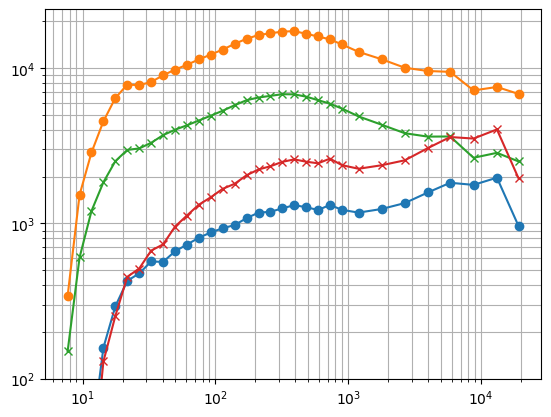

In [22]:
Z = Z_func(*cop24_FC.values(), coo24_FC['hx'], coo24_FC['hy'], bands=bands)
#Z = Z_func(*cop24_FC.values(), bands=bands)
T = 1/f_band
print(T)
om = 2 * np.pi/T
rho_a = 1/(mu_0 * om[:, None, None]) * np.abs(Z)**2

plt.loglog(T, rho_a[:, 1, 0], 'C0', marker='o')
plt.loglog(T, rho_a[:, 0, 1], 'C1', marker='o')
plt.loglog(T, rho_a[:, 1, 1], 'C2', marker='x')
plt.loglog(T, rho_a[:, 0, 0], 'C3', marker='x')

# Z = Z_func(Ex_cal, Ey_cal, Hx_cal, Hy_cal)
# T = 1/f
# om = 2 * np.pi/T
# rho_a = 1/(mu_0 * om[:, None, None]) * np.abs(Z)**2

# # plt.loglog(T, rho_a[:, 1, 0], 'C0', marker='o', linestyle="", alpha=0.05)
# # plt.loglog(T, rho_a[:, 0, 1], 'C1', marker='o', linestyle="", alpha=0.05)
# # plt.loglog(T, rho_a[:, 1, 1], 'C2', marker='x', linestyle="", alpha=0.05)
# # plt.loglog(T, rho_a[:, 0, 0], 'C3', marker='x', linestyle="", alpha=0.05)

plt.ylim([1E2, 24_000])
# plt.xlim([5, 20_000])

plt.grid(which='both')